Part 1

In [2]:
from inverse_solver import InverseSolver
import inverse_solver
import priors
import matplotlib.pyplot as plt
import numpy as np
import pywt
import scipy
import imageio

In [4]:
psf = (plt.imread('img/IMG_0519.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0523.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

solver = InverseSolver(
    psf,
    algorithm="fista",
    num_iters=500,
    prox_fn=priors.prox_nonneg,
    lam = 1e-2
)

x_hat = solver(y)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.635775390676075].


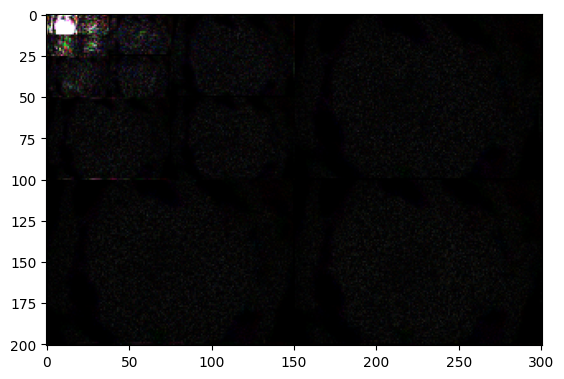

In [5]:
x_hat = (x_hat - x_hat.min()) / (x_hat.max() + 1e-8)

Wx, slices = priors.W(x_hat)

x_recon = priors.WT(Wx, slices)

plt.imshow(np.log1p(np.abs(Wx)))

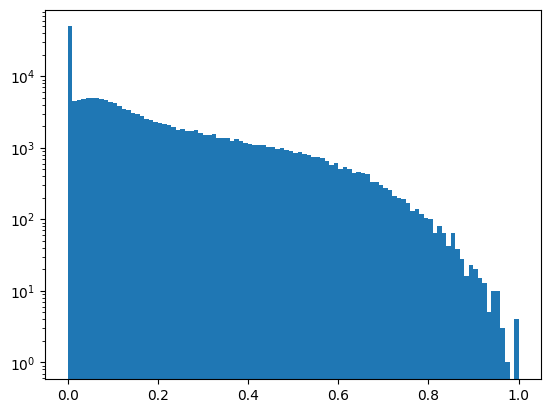

In [34]:
plt.hist(x_recon.flatten(), bins=100)
plt.yscale('log')

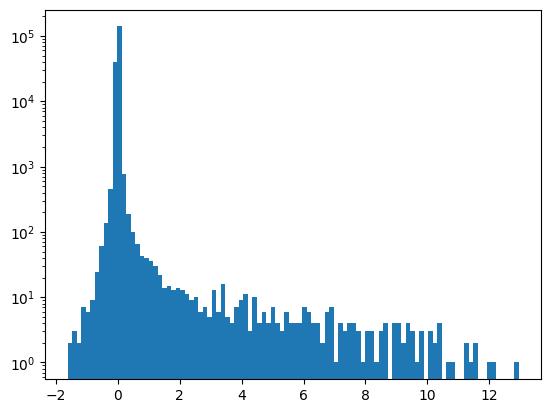

In [35]:
plt.hist(Wx.flatten(), bins=100)
plt.yscale('log')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3877787807814457e-16..0.9999999994832482].


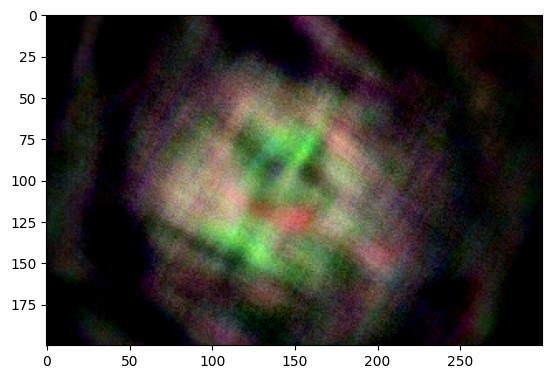

In [36]:
plt.imshow(x_recon)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1373250396010831..0.8501672518809612].


PSNR: 25.30 dB
Nonzero coefficients: 364


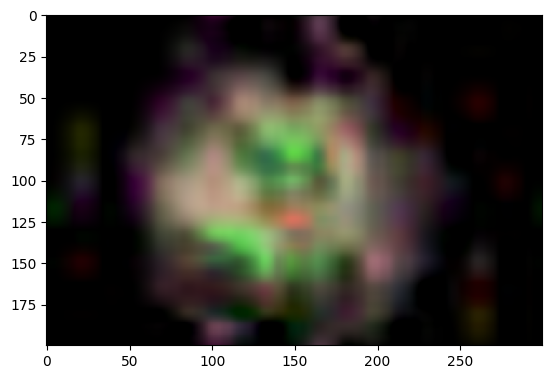

In [8]:
mag = np.abs(Wx).ravel()
thresh = np.percentile(np.abs(Wx), 99.8) 
mask = np.abs(Wx) >= thresh
sparse_Wx = Wx * mask
sparse_recon = priors.WT(sparse_Wx, slices)
PSNR = 10 * np.log10(1 / np.mean((x_hat - sparse_recon) ** 2))
print(f"PSNR: {PSNR:.2f} dB")
num_nonzero = np.sum(mask)
print(f"Nonzero coefficients: {num_nonzero}")
plt.imshow(sparse_recon)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2086137920598332].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1990861905728747].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1388127602824853].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0471063208653117].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.092227944646446].


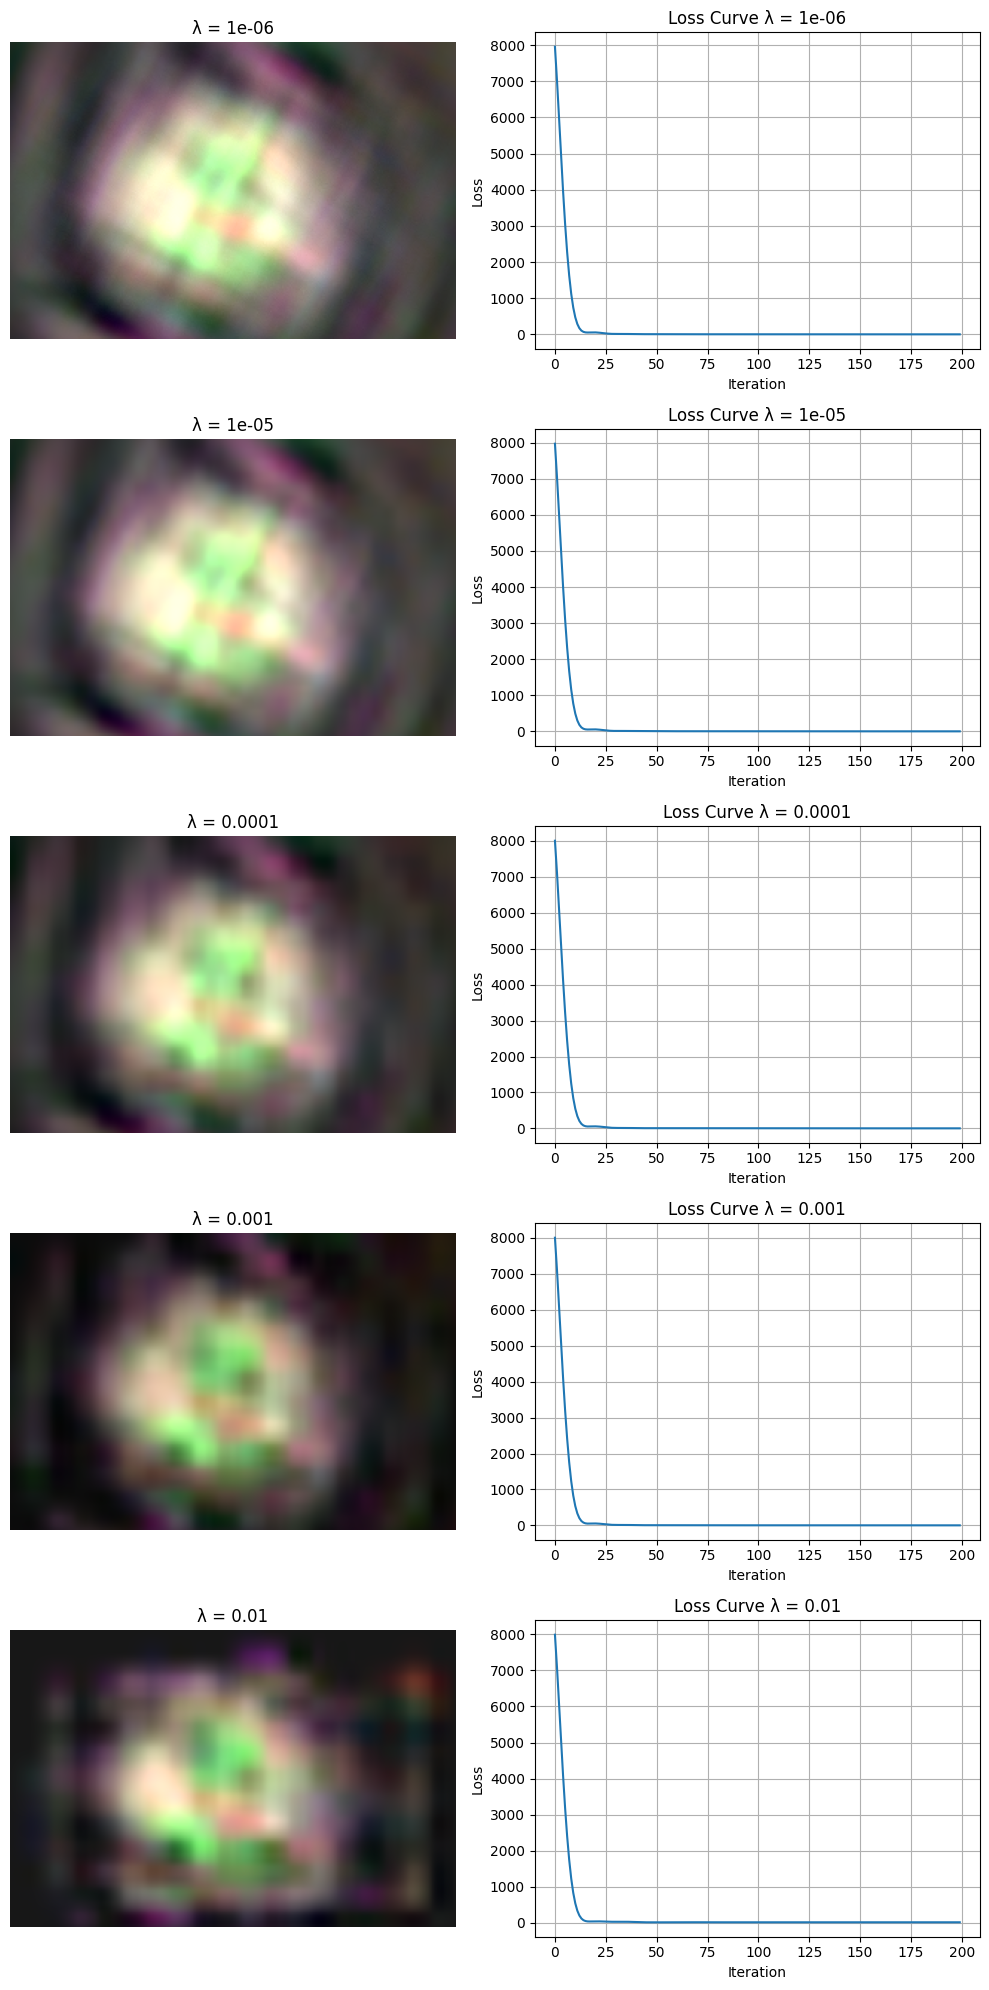

In [17]:
psf = (plt.imread('img/IMG_0519.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0523.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

lambdas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

fig, axes = plt.subplots(len(lambdas), 2, figsize=(10, 4*len(lambdas)))

for i, lam in enumerate(lambdas):
    solver = InverseSolver(psf, algorithm="fista", num_iters=200, prox_fn=priors.prox_wavelet, lam=lam)
    fista = solver(y)
    fista = (fista - fista.min()) / (fista.max() + 1e-8)
    
    axes[i, 0].imshow(fista)
    axes[i, 0].set_title(f"λ = {lam}")
    axes[i, 0].axis('off')
    
    axes[i, 1].plot(solver.losses)
    axes[i, 1].set_title(f"Loss Curve λ = {lam}")
    axes[i, 1].set_xlabel("Iteration")
    axes[i, 1].set_ylabel("Loss")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0006492184494071].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0005447004264025].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000262945618844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000107836656328].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0001360478997].


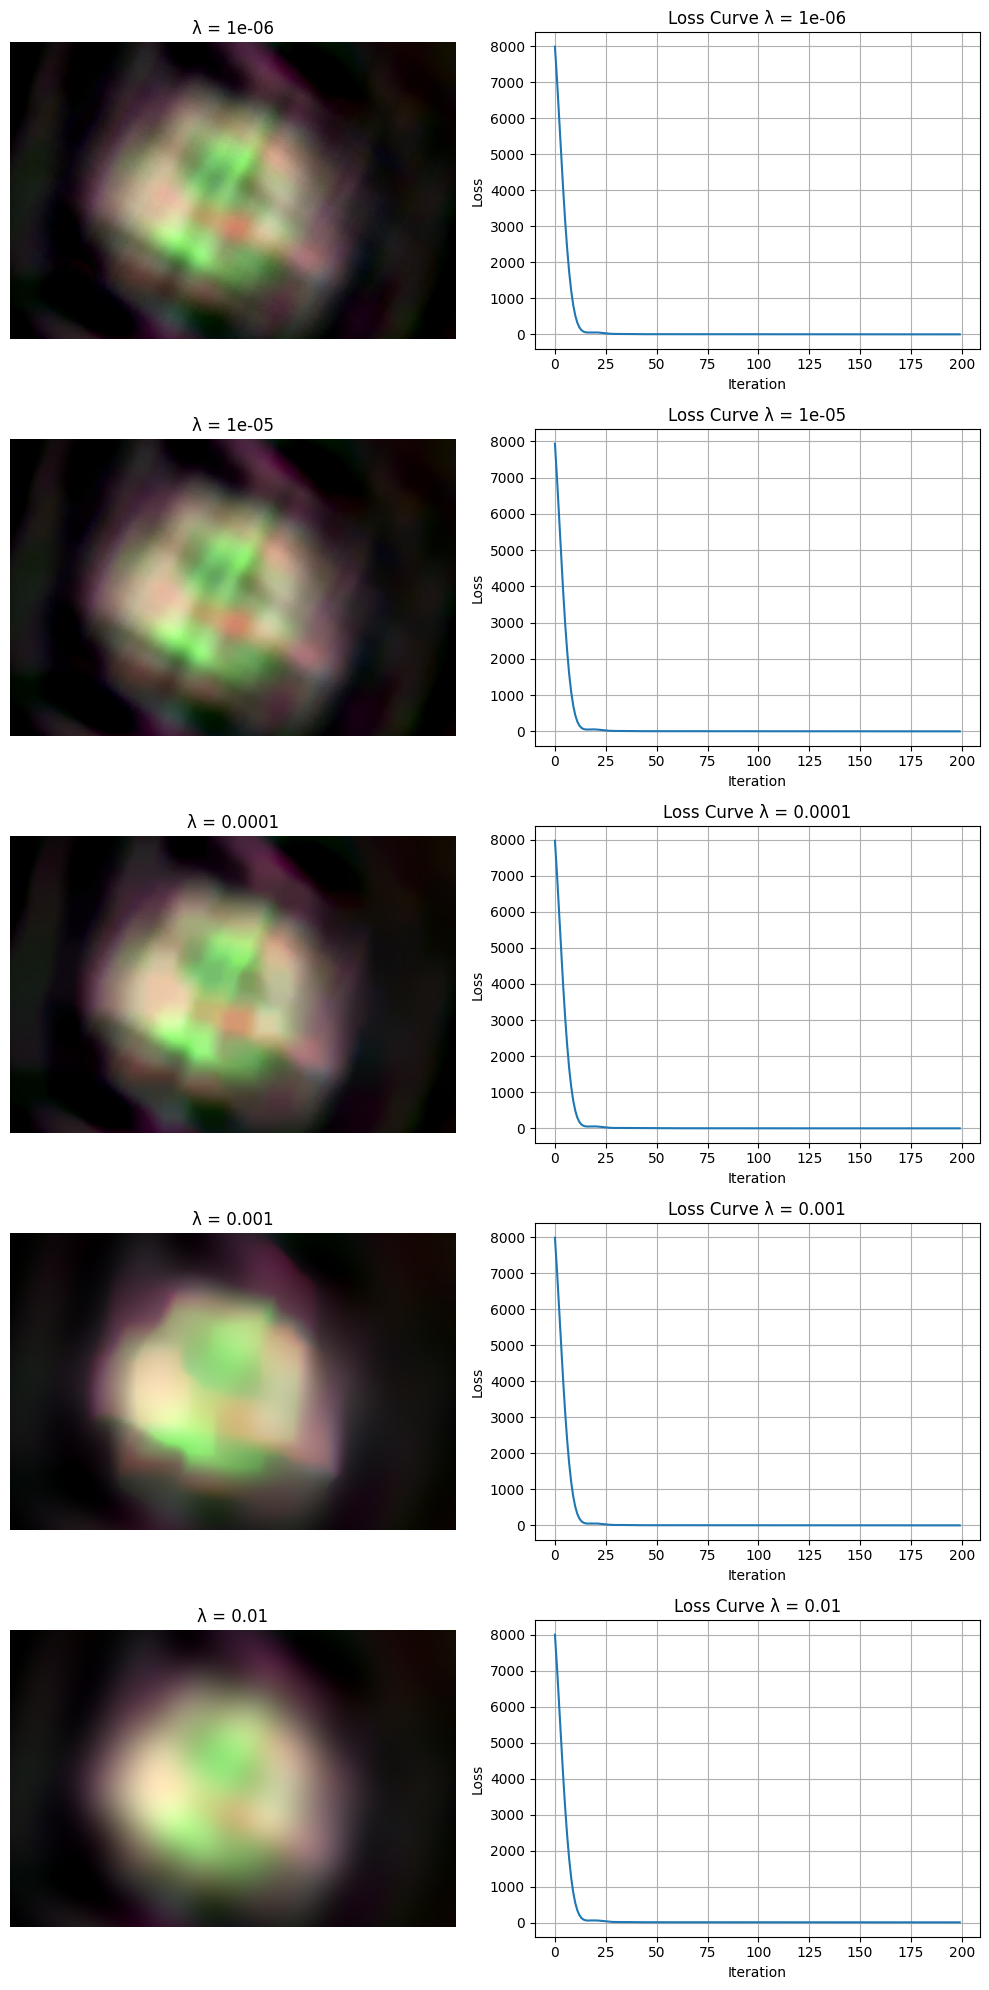

In [6]:
import priors

lambdas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

fig, axes = plt.subplots(len(lambdas), 2, figsize=(10, 4*len(lambdas)))

for i, lam in enumerate(lambdas):
    solver = InverseSolver(psf, algorithm="fista", num_iters=200, prox_fn=priors.prox_tv, lam=lam)
    fista = solver(y)
    fista = (fista - fista.min()) / (fista.max() + 1e-8)
    
    axes[i, 0].imshow(fista)
    axes[i, 0].set_title(f"λ = {lam}")
    axes[i, 0].axis('off')
    
    axes[i, 1].plot(solver.losses)
    axes[i, 1].set_title(f"Loss Curve λ = {lam}")
    axes[i, 1].set_xlabel("Iteration")
    axes[i, 1].set_ylabel("Loss")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
num_iters = 200
lambdas = [1e-5, 1e-4, 1e-3, 1e-2]
results = {1e-5: {priors.prox_nonneg: None, priors.prox_native: None, priors.prox_wavelet: None, priors.prox_tv: None}, 
           1e-4: {priors.prox_nonneg: None, priors.prox_native: None, priors.prox_wavelet: None, priors.prox_tv: None}, 
           1e-3: {priors.prox_nonneg: None, priors.prox_native: None, priors.prox_wavelet: None, priors.prox_tv: None}, 
           1e-2: {priors.prox_nonneg: None, priors.prox_native: None, priors.prox_wavelet: None, priors.prox_tv: None}}
models = [priors.prox_nonneg, priors.prox_native, priors.prox_wavelet, priors.prox_tv]

for lam in lambdas:
    for model in models:
        y = InverseSolver(psf, algorithm="fista", num_iters=num_iters,
                                   prox_fn=model, lam=lam)
        
        recon = solver(y)
        
        results[lam][model] = recon

In [ ]:
import matplotlib.pyplot as plt

def show(ax, img, title):
    ax.imshow(np.clip(img, 0, 1) if img.shape[-1] == 3
              else np.clip(img[:,:,0], 0, 1), cmap="gray")
    ax.set_title(title, fontsize=8)
    ax.axis("off")

col_titles = ["Meas (random)", "Recon NN", "Recon TV",
              "Meas (rect)",   "Recon NN", "Recon TV"]

fig, axes = plt.subplots(len(lambdas) + 1, 6, figsize=(16, 4*(len(lambdas)+1)))

for j in range(6):
    axes[0, j].axis("off")

for i, r in enumerate(results):
    row = axes[i]
    show(row[0], r["y_rand"],  f"Random {int(r['frac']*100)}% kept")
    show(row[1], r["rand_nn"], "Rand → NN")
    show(row[2], r["rand_tv"], "Rand → TV")
    show(row[3], r["y_rect"],  f"Rect {int(r['frac']*100)}% kept")
    show(row[4], r["rect_nn"], "Rect → NN")
    show(row[5], r["rect_tv"], "Rect → TV")

plt.suptitle("Compressive Reconstruction: Random vs Structured Masking", fontsize=12)
plt.tight_layout()
plt.show()

Part 3

In [9]:
def dct_matrix(n):
    D = np.zeros((n, n))
    for k in range(n):
        for i in range(n):
            D[k, i] = np.cos(np.pi * k * (2*i + 1) / (2*n))
    D[0, :] *= 1 / np.sqrt(n)
    D[1:, :] *= np.sqrt(2 / n)
    return D

def mutual_coherence(A):
    A_normalized = A / np.linalg.norm(A, axis=0, keepdims=True)
    G = A_normalized.T @ A_normalized
    np.fill_diagonal(G, 0)
    return np.max(np.abs(G))

def cross_coherence(A, B):
    A_normalized = A / np.linalg.norm(A, axis=0, keepdims=True)
    B_normalized = B / np.linalg.norm(B, axis=0, keepdims=True)
    G = A_normalized.T @ B_normalized
    return np.max(np.abs(G))

In [20]:
A = np.random.randn(32, 64)
D = dct_matrix(64)[:32, :]

print("Mutual Coherence of A:", mutual_coherence(A))
print("Mutual Coherence of D:", mutual_coherence(D))
print("Cross Coherence between A and D:", cross_coherence(A, D))

Mutual Coherence of A: 0.5795255905404952
Mutual Coherence of D: 0.6701408134272816
Cross Coherence between A and D: 0.5488702593595665


In [11]:
A_noisy = A + 0.1 * np.random.randn(32, 64)
print("Cross Coherence between A and A_noisy:", cross_coherence(A, A_noisy))

Cross Coherence between A and A_noisy: 0.9978641757516638


In [21]:
def random_mask(y, keep_fraction):
    mask_flat = np.ones(np.prod(y.shape))
    n_zero = int (len(mask_flat) * (1-keep_fraction))
    mask_flat[:n_zero] = 0
    np.random.shuffle(mask_flat)
    return mask_flat.reshape(y.shape)

def rect_mask(y, keep_frac):
    mask = np.ones_like(y)
    h, w = y.shape[:2]
    rect_h = int(h * np.sqrt(1 - keep_frac))
    rect_w = int(w * np.sqrt(1 - keep_frac))
    r0 = (h - rect_h) // 2
    c0 = (w - rect_w) // 2
    mask[r0:r0+rect_h, c0:c0+rect_w] = 0
    return mask

In [23]:
psf = (plt.imread('img/IMG_0519.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0523.jpg').astype(np.float64)) / 255.0

psf = psf[::20, ::20, :]
y = dif[::20, ::20, :]

solver = InverseSolver(
    psf,
    algorithm="fista",
    num_iters=200,
    prox_fn=priors.prox_tv,
    lam = 1e-2, 
    mask = random_mask(y, .5)
)

lhs, rhs = inverse_solver.adjoint_test(solver, y.shape)
print(lhs, rhs)
print(lhs - rhs)

solver = InverseSolver(
    psf,
    algorithm="fista",
    num_iters=200,
    prox_fn=priors.prox_nonneg,
    lam = 1e-2, 
    mask = random_mask(y, .5)
)

lhs, rhs = inverse_solver.adjoint_test(solver, y.shape)
print(lhs, rhs)
print(lhs - rhs)

0.06028653503869991 0.06028653503869914
7.632783294297951e-16
0.13007330187680094 0.13007330187680016
7.771561172376096e-16


In [24]:
fractions  = [0.50, 0.10, 0.05]
num_iters  = 200
lam_tv     = 1e-2
lam_nn     = 0.0 

results = []

for frac in fractions:
    
    rand_mask  = random_mask(y, frac)
    y_rand     = y * rand_mask

    recon_rand_nn = InverseSolver(psf, algorithm="fista", num_iters=num_iters,
                                   prox_fn=priors.prox_nonneg, lam=lam_nn,
                                   mask=rand_mask)(y_rand)

    recon_rand_tv = InverseSolver(psf, algorithm="fista", num_iters=num_iters,
                                   prox_fn=priors.prox_tv, lam=lam_tv,
                                   mask=rand_mask)(y_rand)

    rect_masky  = rect_mask(y, frac)
    y_rect     = y * rect_masky

    recon_rect_nn = InverseSolver(psf, algorithm="fista", num_iters=num_iters,
                                   prox_fn=priors.prox_nonneg, lam=lam_nn,
                                   mask=rect_masky)(y_rect)

    recon_rect_tv = InverseSolver(psf, algorithm="fista", num_iters=num_iters,
                                   prox_fn=priors.prox_tv, lam=lam_tv,
                                   mask=rect_masky)(y_rect)

    results.append(dict(frac=frac,
                        y_rand=y_rand,     y_rect=y_rect,
                        rand_nn=recon_rand_nn, rand_tv=recon_rand_tv,
                        rect_nn=recon_rect_nn, rect_tv=recon_rect_tv))

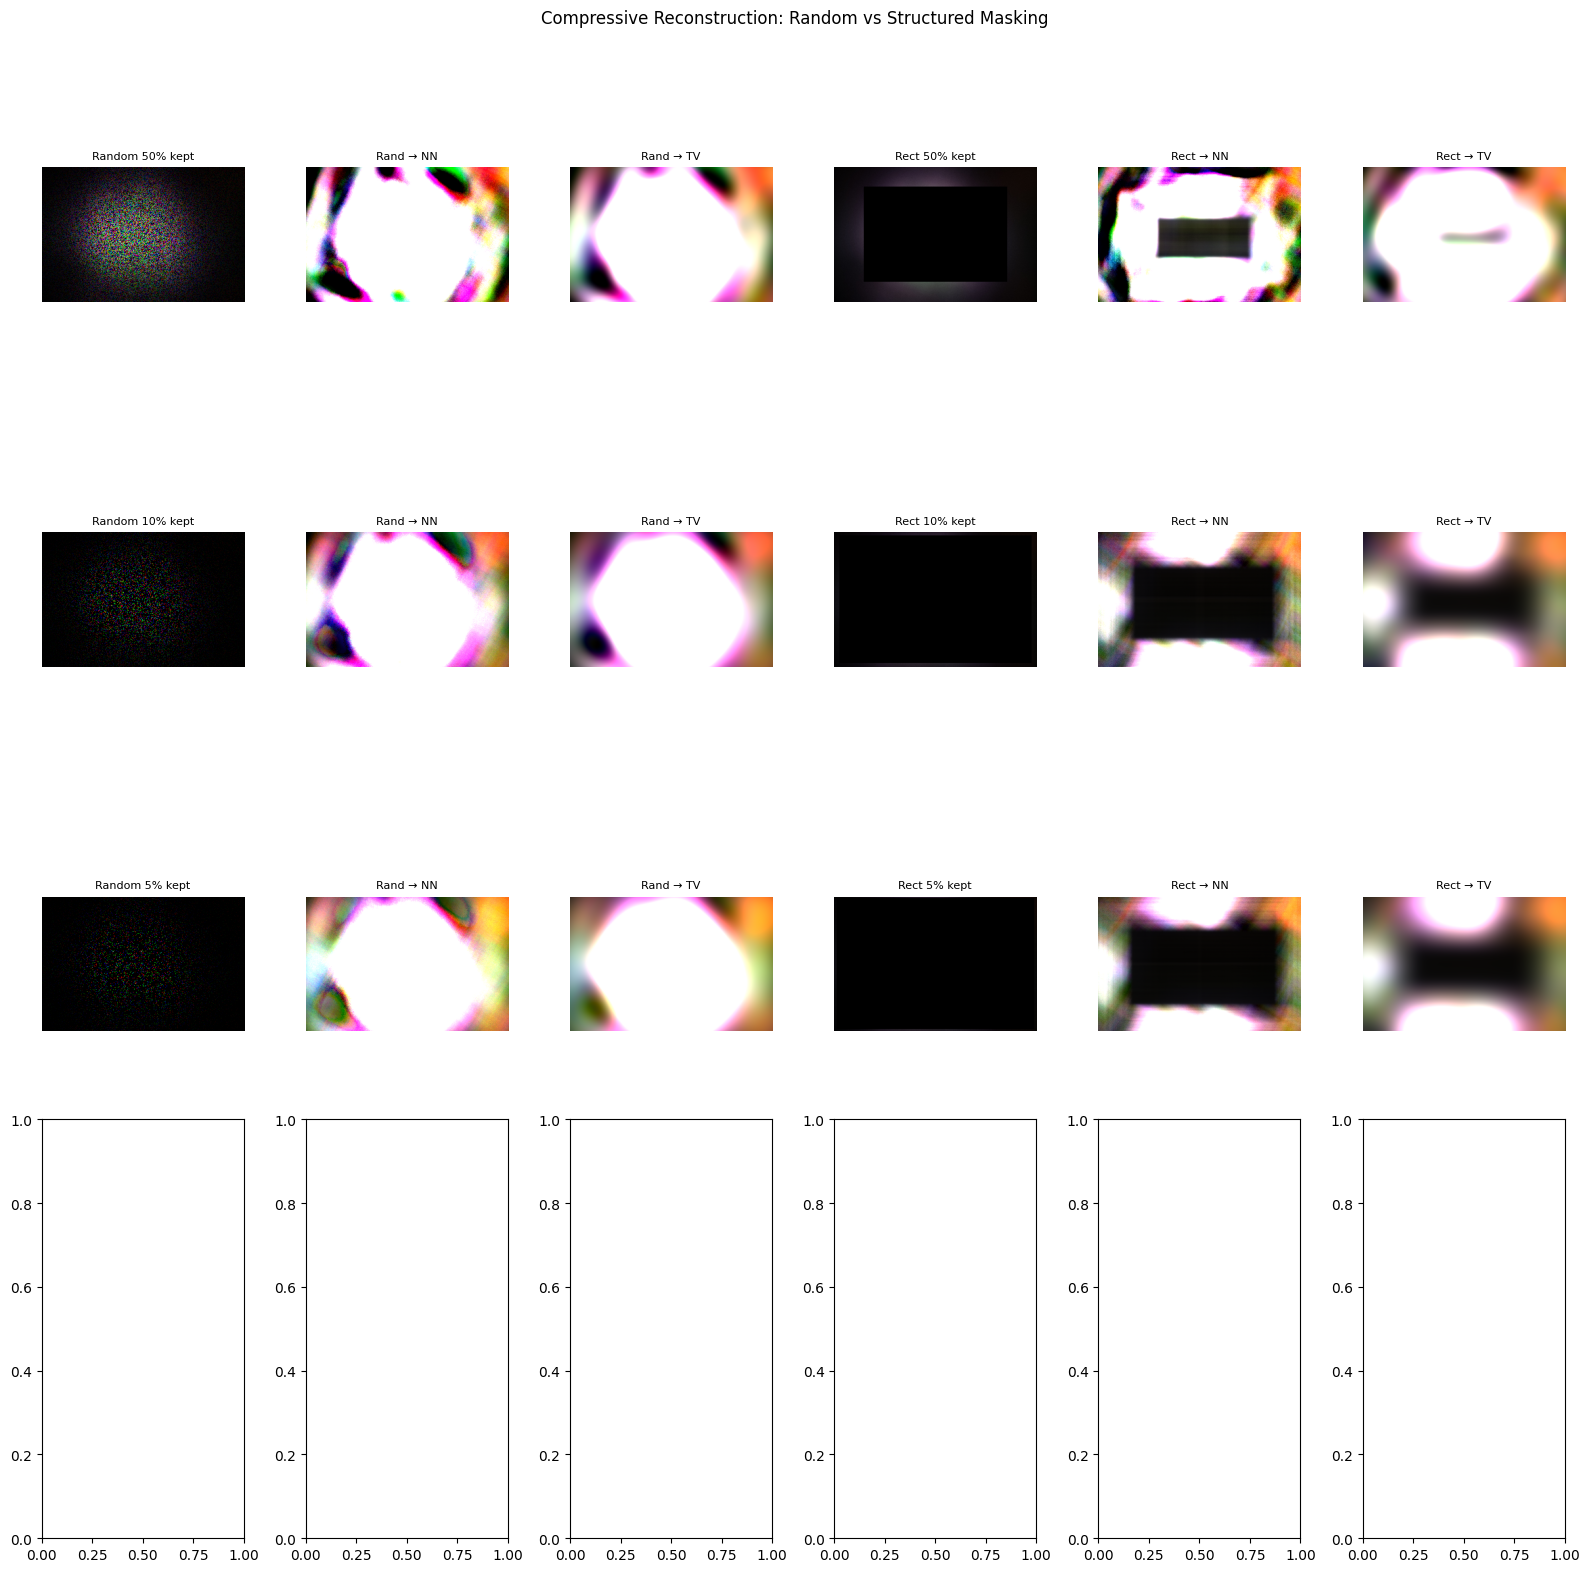

In [25]:
import matplotlib.pyplot as plt

def show(ax, img, title):
    ax.imshow(np.clip(img, 0, 1) if img.shape[-1] == 3
              else np.clip(img[:,:,0], 0, 1), cmap="gray")
    ax.set_title(title, fontsize=8)
    ax.axis("off")

col_titles = ["Meas (random)", "Recon NN", "Recon TV",
              "Meas (rect)",   "Recon NN", "Recon TV"]

fig, axes = plt.subplots(len(fractions) + 1, 6, figsize=(16, 4*(len(fractions)+1)))

for j in range(6):
    axes[0, j].axis("off")

for i, r in enumerate(results):
    row = axes[i]
    show(row[0], r["y_rand"],  f"Random {int(r['frac']*100)}% kept")
    show(row[1], r["rand_nn"], "Rand → NN")
    show(row[2], r["rand_tv"], "Rand → TV")
    show(row[3], r["y_rect"],  f"Rect {int(r['frac']*100)}% kept")
    show(row[4], r["rect_nn"], "Rect → NN")
    show(row[5], r["rect_tv"], "Rect → TV")

plt.suptitle("Compressive Reconstruction: Random vs Structured Masking", fontsize=12)
plt.tight_layout()
plt.show()